##**Reto M3-04 Reto4**
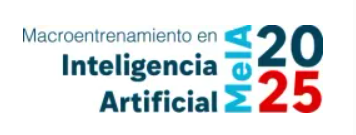



#**Clasificación de sitios de unión a factores de transcripción de bacterias**

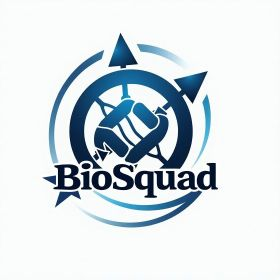


**Integrantes:**
- Conde Chuqumia Héctor René
- Guardado Méndez Alejandra
- Maximiliano Adauto Alejandro
- Velasco Pichardo María Biaanni





### **OBJETIVO**

*Desarrollar un modelo predictivo capaz de identificar TFBS en bacterias, mediante el uso de técnicas de IA aplicadas a datos biológicos, abordando su preprocesamiento, análisis y validación.*

### **PROCEDIMIENTO**


1.   Elección del dataset a usar de TFBS
2.   Pre-procesamiento de datos
3.   Análisis de datos mediante el algoritmo Random Forest
6. Discusión y conclusiones







#### **1. ELECCION DEL DATASET A USAR DE TFBS**

Se contó con dos dataset de secuencias en formato fasta : uno general y el otro dirigido al RegulonDB en *Escherichia coli*. De esta manera se eligió una mezcla de los dos en aras de evitar un modelo demasiado dirigido. Se usó el paquete Biopython para curar las secuencias.

En este caso la curación de los datos consistió en eliminar los comentarios de los formatos fasta y otras etiquetas para dejar las secuencias y poder analizarlas. Asimismo se elminaron secuencias repetidas

#### **1. PRE-PROCESAMIENTO DE DATOS**
Se utilizó la librería *Biopython* para acceder a datos genómicos de Escherichia coli K-12 substr. MG1655 obtenidos del NCBI mediante el módulo Entrez de Biopython, lo que asegura acceso a información actualizada y confiable. Se descargaron dos archivos clave: un archivo FASTA (.fna), que contiene únicamente la secuencia de nucleótidos y se emplea para extraer subsecuencias negativas que no se superpongan con regiones reguladoras, y un archivo GenBank (.gbff), que incluye anotaciones funcionales como genes y promotores, esencial para evitar que las regiones negativas contengan elementos biológicos relevantes.

In [ ]:
!pip install biopython

from Bio import Entrez, SeqIO

# Usa tu correo electrónico real aquí
Entrez.email = "hectorchuquimia123@gmail.com"

# === Descargar genoma completo de E. coli K12 MG1655 ===
def descargar_genoma_ecoli():
    print("📥 Descargando secuencia FASTA...")
    handle = Entrez.efetch(db="nucleotide", id="U00096", rettype="fasta", retmode="text")
    record = SeqIO.read(handle, "fasta")
    with open("ecoli_genoma.fna", "w") as f:
        SeqIO.write(record, f, "fasta")
    print("✅ Genoma guardado como ecoli_genoma.fna")

# === Descargar archivo GenBank con anotaciones ===
def descargar_gbff_ecoli():
    print("📥 Descargando anotaciones GenBank (gbff)...")
    handle = Entrez.efetch(db="nucleotide", id="U00096", rettype="gbwithparts", retmode="text")
    with open("ecoli_genoma.gbff", "w") as f:
        f.write(handle.read())
    print("✅ Anotaciones guardadas como ecoli_genoma.gbff")

# Ejecutar descargas
descargar_genoma_ecoli()
descargar_gbff_ecoli()

TRATAMOS COLECT TF

In [ ]:
import os

# Crear carpeta de salida si no existe
os.makedirs("CollecTF_FASTA_CORREGIDO", exist_ok=True)

# Carpeta de entrada
entrada = "CollecTF_FASTA"
salida = "CollecTF_FASTA_CORREGIDO"

# Convertir todos los archivos .fasta del directorio
for archivo in os.listdir(entrada):
    if archivo.endswith(".fasta"):
        path_in = os.path.join(entrada, archivo)
        path_out = os.path.join(salida, archivo)

        with open(path_in, "r") as fin, open(path_out, "w") as fout:
            i = 1
            for linea in fin:
                sec = linea.strip()
                if sec:
                    fout.write(f">seq{i}\n{sec}\n")
                    i += 1

print("✅ Todos los archivos han sido convertidos y guardados en 'CollecTF_FASTA_CORREGIDO'")

COMBINAMOS LOS DATASETS DE TFBS NEGATIVOS GENERADOS Y LOS POSITIVOS DE REGULON

In [ ]:
from Bio import SeqIO
import pandas as pd
import os
import random

# === 1. Leer genoma ===
genoma_record = SeqIO.read("ecoli_genoma.fna", "fasta")
genoma = str(genoma_record.seq).upper()

# === 2. Leer genes desde archivo GenBank ===
def extraer_genes_gbff(path):
    genes = []
    record = SeqIO.read(path, "genbank")
    for feature in record.features:
        if feature.type == "gene":
            start = int(feature.location.start)
            end = int(feature.location.end)
            genes.append((start, end))
    return sorted(genes)

genes = extraer_genes_gbff("ecoli_genoma.gbff")
print(f"✅ Genes encontrados: {len(genes)}")

# === 3. Extraer regiones intergénicas ===
intergenicas = []
for i in range(len(genes) - 1):
    end1 = genes[i][1]
    start2 = genes[i + 1][0]
    if start2 - end1 >= 30:
        inter = genoma[end1:start2]
        intergenicas.append(inter)

print(f"✅ Regiones intergénicas extraídas: {len(intergenicas)}")

# === 4. Leer secuencias positivas desde carpeta corregida ===
positivas = []
ruta_fasta = "CollecTF_FASTA_CORREGIDO"

for archivo in os.listdir(ruta_fasta):
    if archivo.endswith(".fasta"):
        familia = archivo.replace(".fasta", "")
        path = os.path.join(ruta_fasta, archivo)
        for record in SeqIO.parse(path, "fasta"):
            sec = str(record.seq).upper()
            if set(sec) <= set("ACGT"):
                positivas.append({
                    "secuencia": sec,
                    "familia": familia,
                    "clase": 1
                })

df_pos = pd.DataFrame(positivas)
print(f"✅ Secuencias positivas: {len(df_pos)}")

# === 5. Generar secuencias negativas realistas ===
negativas = []
for l in df_pos["secuencia"].str.len():
    intentos = 0
    while intentos < 10:
        region = random.choice(intergenicas)
        if len(region) >= l:
            start = random.randint(0, len(region) - l)
            subseq = region[start:start + l]
            negativas.append({
                "secuencia": subseq,
                "familia": "intergenica",
                "clase": 0
            })
            break
        intentos += 1

df_neg = pd.DataFrame(negativas)
print(f"✅ Secuencias negativas: {len(df_neg)}")

# === 6. Combinar y guardar ===
df_total = pd.concat([df_pos, df_neg]).sample(frac=1).reset_index(drop=True)
df_total.to_csv("dataset_tfbs_completo.csv", index=False)
print("📁 Dataset guardado como 'dataset_tfbs_completo.csv'")

GENERAMOS NEGATIVOS ALEATORIOS

In [ ]:
import random
import pandas as pd

def generar_negativos_aleatorios(cantidad, longitud=30):
    bases = ["A", "C", "G", "T"]
    secuencias = []
    for _ in range(cantidad):
        seq = ''.join(random.choices(bases, k=longitud))
        secuencias.append({
            "secuencia": seq,
            "familia": "aleatoria",
            "clase": 0
        })
    return pd.DataFrame(secuencias)

df_aleatorios = generar_negativos_aleatorios(cantidad=500, longitud=30)
print(f"✅ Negativos aleatorios: {df_aleatorios.shape}")

In [ ]:
LEER REGULON

In [ ]:
from Bio import SeqIO
import os
import pandas as pd

# === 1. Leer los archivos de RegulonDB
ruta_regulon = "RegulonDB"
secuencias_regulon = []

for archivo in os.listdir(ruta_regulon):
    if archivo.endswith(".faa"):
        familia = archivo.replace(".faa", "")
        path = os.path.join(ruta_regulon, archivo)
        for record in SeqIO.parse(path, "fasta"):
            sec = str(record.seq).upper()
            # Validar que contiene solo ACGT
            if set(sec).issubset({"A", "C", "G", "T"}):
                secuencias_regulon.append({
                    "secuencia": sec[:30],  # cortar o padear si es necesario
                    "familia": f"regulon_{familia}",
                    "clase": 1
                })

df_regulon = pd.DataFrame(secuencias_regulon)
print(f"✅ Secuencias positivas extraídas de RegulonDB: {len(df_regulon)}")
df_regulon.head()

GENERAMOS LOS NEGATIVOS PARA JUNTAR

In [ ]:
import random

def generar_negativos_aleatorios(cantidad, longitud=30):
    bases = ["A", "C", "G", "T"]
    negativos = []
    for _ in range(cantidad):
        seq = ''.join(random.choices(bases, k=longitud))
        negativos.append({
            "secuencia": seq,
            "familia": "aleatoria",
            "clase": 0
        })
    return pd.DataFrame(negativos)

df_aleatorios = generar_negativos_aleatorios(500, longitud=30)
print(f"✅ Secuencias negativas aleatorias: {len(df_aleatorios)}")
df_aleatorios.head()

JUNTAMOS LOS NEGATIVOS ALEATORIOS CON LOS POSITIVOS DE REGULO

In [ ]:
df_extra = pd.concat([df_regulon, df_aleatorios]).sample(frac=1).reset_index(drop=True)
df_extra.to_csv("dataset_extra_RegulonDB_y_negativos.csv", index=False)
print("📁 Guardado como 'dataset_extra_RegulonDB_y_negativos.csv'")

LO FUSIONAMOS CON EL DATASET DE COLLECTF Y LOS NEGATIVOS GENERADOS A PARTIR DE *E. coli*

In [ ]:
df1 = pd.read_csv("dataset_tfbs_completo.csv")
df2 = pd.read_csv("dataset_extra_RegulonDB_y_negativos.csv")

df_fusionado = pd.concat([df1, df2]).sample(frac=1).reset_index(drop=True)
df_fusionado.to_csv("dataset_tfbs_fusionado.csv", index=False)

print("📁 Dataset fusionado guardado como 'dataset_tfbs_fusionado.csv'")

#### 3. **ANÁLISIS DE DATOS MEDIANTE EL ALGORITMO RANDOM FOREST**

En este caso fue conveniente usar el Random Forest, gracias a la familiaridad y comodidad proporcionada, tambien que los datos de entrada al secuencias de ADN las cuales teniamos que transformar en números, lo que nos permite trabajar directamente con esos valores sin requerir escalado o normalizacion, a diferencia de otros modelos como SVM o regresiones.

Además, su bajo requerimiento de preprocesamiento y su rendimiento eficiente en conjuntos de datos bioinformáticos de tamaño moderado los hace especialmente adecuados para esta aplicación.


1. *Modelo TFBS usando dataset_tfbs_completo

In [ ]:
# === Modelo TFBS usando dataset_tfbs_completo.csv con ajuste de hiperparámetros ===

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# === 1. Cargar y preparar dataset ===
df = pd.read_csv("dataset_tfbs_fusionado.csv")
print("✅ Dataset cargado:", df.shape)

# === 2. Preprocesamiento de secuencias ===
L = 30

def limpiar(seq):
    return ''.join([b for b in seq.upper() if b in "ACGT"])

def ajustar_longitud(seq, L):
    if len(seq) > L:
        return seq[:L]
    return seq + "N" * (L - len(seq))

df["secuencia"] = df["secuencia"].apply(limpiar)
df = df[df["secuencia"].str.len() >= 10].reset_index(drop=True)
df["secuencia"] = df["secuencia"].apply(lambda s: ajustar_longitud(s, L))

# === 3. Codificación stacking con más propiedades ===
stacking = {
    'AA': [-1.00, -7.9, -22.2], 'AC': [-1.44, -8.4, -22.4], 'AG': [-1.28, -7.8, -21.0], 'AT': [-0.88, -7.2, -20.4],
    'CA': [-1.45, -8.5, -22.7], 'CC': [-1.00, -8.0, -19.9], 'CG': [-1.84, -10.6, -27.2], 'CT': [-1.00, -7.8, -20.8],
    'GA': [-1.30, -8.2, -22.2], 'GC': [-2.24, -9.8, -24.4], 'GG': [-1.30, -8.0, -19.9], 'GT': [-1.00, -8.4, -22.4],
    'TA': [-0.58, -7.2, -21.3], 'TC': [-1.28, -8.2, -22.2], 'TG': [-1.45, -8.5, -22.7], 'TT': [-1.00, -7.9, -22.2],
    'NN': [-1.00, -7.0, -20.0]
}

def codificar_stack(seq, L, tabla):
    matriz = []
    for i in range(L - 1):
        par = seq[i:i+2]
        if 'N' in par or len(par) != 2:
            par = 'NN'
        matriz.append(tabla.get(par, [-1.00, -7.0, -20.0]))
    return np.array(matriz)

# === 4. Codificación del dataset ===
X = np.array([codificar_stack(s, L, stacking) for s in df["secuencia"]])
X = X.reshape(X.shape[0], -1)
y = df["clase"].values

print(f"✅ X shape: {X.shape} (muestras, features={X.shape[1]})")
print(f"✅ y shape: {y.shape}")

# === 5. Separar datos ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("✅ División lista: ")
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

# === 6. Búsqueda de hiperparámetros ampliada ===
param_grid = {
    'n_estimators': [300, 500, 1000],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 4, 6],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42),
                           param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("✅ Mejor combinación encontrada:", grid_search.best_params_)
clf = grid_search.best_estimator_

# === Guardar el modelo entrenado ===
joblib.dump(clf, "modelo_rf_ajustado.pkl")

# === 7. Evaluación con validación cruzada ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=skf, scoring='f1')
print(f"\n🎯 F1-score promedio (5 folds): {scores.mean():.4f}")

# === 8. Evaluación final ===
y_prob = clf.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.45).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n📊 Modelo RandomForest con mejores hiperparámetros")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

# === 9. Matriz de confusión ===
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No TFBS", "TFBS"]).plot(cmap="Blues")
plt.title("Matriz de Confusión")
plt.show()

# === 10. Distribución de probabilidades ===
sns.histplot(y_prob, bins=20, kde=True)
plt.axvline(0.45, color='red', linestyle='--', label='Umbral 0.45')
plt.title("Distribución de Probabilidades TFBS")
plt.xlabel("Probabilidad predicha")
plt.legend()
plt.show()

# === 11. Guardar predicción final ===
df_test = pd.read_csv("test.csv", sep='\t')
df_test["secuencia"] = df_test["Sequence"].apply(limpiar).apply(lambda s: ajustar_longitud(s, L))
X_nuevo = np.array([codificar_stack(s, L, stacking) for s in df_test["secuencia"]])
X_nuevo_flat = X_nuevo.reshape(X_nuevo.shape[0], -1)
y_pred_test = clf.predict(X_nuevo_flat)

# Guardar en formato requerido
df_salida = df_test[["id"]].copy()
df_salida["is_tfbs"] = y_pred_test
df_salida.to_csv("1prediccionmodelo_rf_ajustado.csv", sep='\t', index=False)
print("📁 Resultado guardado como '1prediccionmodelo_rf_ajustado.csv'")


#### 4. **Discusión y conclusiones**
Durante el desarrollo del trabajo, se compararon dos modelos predictivos: uno construido a partir de un conjunto de datos ampliado, y otro entrenado sobre un subconjunto más restringido y curado de secuencias. Si bien el primer modelo presentaba una mayor cantidad de instancias, su desempeño en términos de precisión y el primero fue inferior al del segundo, el cual, a pesar de contar con menos datos, alcanzó un puntaje de 95%
Este comportamiento se puede explicar por la calidad y especificidad de los datos utilizados. El conjunto reducido presenta mayor accurracy pero menor estabilidad,el conjunto fusionado con collecTF,RegulonDB y negativos extraidos de la bacteria Ecolly y generados aleatoriamente es mas estable al tener mas datos.